In [16]:
%pip install pandas numpy matplotlib seaborn scikit-learn contextily

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Phase 1: Feature Engineering and Baseline Modeling
**Capstone Project:** Population & Economic Dynamics in Puerto Rico

As outlined in our predictive framework, this notebook establishes the data foundation and baseline performance metrics. Before deploying complex non-linear models (like Random Forest), we must first clean the data, engineer domain-specific features, and train a straightforward baseline model (Ordinary Least Squares Linear Regression) to serve as our benchmark.

### The Predictive Pipeline


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from math import radians, cos, sin, asin, sqrt

# Scikit-Learn modules
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Helper function for geographic distance
def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon, dlat = lon2 - lon1, lat2 - lat1 
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return 2 * asin(sqrt(a)) * 6371 # Radius of earth in km

## 1. Data Ingestion & Preprocessing
We begin by loading our consolidated master dataset, which includes Census population estimates, vital statistics (births/deaths), employer establishments, CDC Social Vulnerability Index (SVI) metrics, and historical hurricane tracks.


In [18]:

# Load the master profile
df = pd.read_csv('../data/puerto_rico_master_profile.csv')

# Standardize municipio names
df['municipio'] = df['municipio'].str.replace(' Municipio', '', case=False).str.strip()

# Sort for time-series operations
df = df.sort_values(by=['municipio', 'year']).reset_index(drop=True)

# Add Municipality Centroids for spatial matching
municipio_coords = {
    'Adjuntas': (18.1627, -66.7222), 'Aguada': (18.3605, -67.1882), 'Aguadilla': (18.4275, -67.1541),
    'Aguas Buenas': (18.2572, -66.1031), 'Aibonito': (18.1408, -66.2663), 'Añasco': (18.2827, -67.1399),
    'Arecibo': (18.4724, -66.7157), 'Arroyo': (17.9658, -66.0614), 'Barceloneta': (18.4505, -66.5385),
    'Barranquitas': (18.1861, -66.3061), 'Bayamón': (18.3808, -66.1557), 'Cabo Rojo': (18.0866, -67.1457),
    'Caguas': (18.2325, -66.0391), 'Camuy': (18.4838, -66.8450), 'Canóvanas': (18.3791, -65.9011),
    'Carolina': (18.3808, -65.9574), 'Cataño': (18.4388, -66.1182), 'Cayey': (18.1119, -66.1663),
    'Ceiba': (18.2633, -65.6474), 'Ciales': (18.3361, -66.4688), 'Cidra': (18.1758, -66.1617),
    'Coamo': (18.0855, -66.3579), 'Comerío': (18.2183, -66.2257), 'Corozal': (18.3411, -66.3161),
    'Culebra': (18.3030, -65.3010), 'Dorado': (18.4588, -66.2677), 'Fajardo': (18.3258, -65.6524),
    'Florida': (18.3625, -66.5614), 'Guánica': (17.9716, -66.9080), 'Guayama': (17.9741, -66.1100),
    'Guayanilla': (18.0130, -66.7919), 'Guaynabo': (18.3580, -66.1111), 'Gurabo': (18.2544, -65.9728),
    'Hatillo': (18.4863, -66.8250), 'Hormigueros': (18.1397, -67.1274), 'Humacao': (18.1497, -65.8274),
    'Isabela': (18.5011, -67.0247), 'Jayuya': (18.2186, -66.5916), 'Juana Díaz': (18.0525, -66.5064),
    'Juncos': (18.2275, -65.9211), 'Lajas': (18.0497, -67.0594), 'Lares': (18.2947, -66.8771),
    'Las Marías': (18.2514, -66.9922), 'Las Piedras': (18.1827, -65.8661), 'Loíza': (18.4330, -65.8797),
    'Luquillo': (18.3725, -65.7166), 'Manatí': (18.4274, -66.4922), 'Maricao': (18.1808, -66.9799),
    'Maunabo': (18.0072, -65.8994), 'Mayagüez': (18.2011, -67.1397), 'Moca': (18.3947, -67.1131),
    'Morovis': (18.3258, -66.4053), 'Naguabo': (18.2119, -65.7350), 'Naranjito': (18.3008, -66.2447),
    'Orocovis': (18.2269, -66.4411), 'Patillas': (18.0066, -66.0161), 'Peñuelas': (18.0622, -66.7219),
    'Ponce': (18.0111, -66.6141), 'Quebradillas': (18.4738, -66.9385), 'Rincón': (18.3403, -67.2500),
    'Río Grande': (18.3794, -65.8311), 'Sabana Grande': (18.0777, -66.9605), 'Salinas': (17.9775, -66.2974),
    'San Germán': (18.0816, -67.0400), 'San Juan': (18.4655, -66.1057), 'San Lorenzo': (18.1894, -65.9611),
    'San Sebastián': (18.3372, -66.9905), 'Santa Isabel': (17.9666, -66.4050), 'Toa Alta': (18.3883, -66.2485),
    'Toa Baja': (18.4438, -66.2591), 'Trujillo Alto': (18.3547, -66.0072), 'Utuado': (18.2655, -66.7005),
    'Vega Alta': (18.4119, -66.3314), 'Vega Baja': (18.4438, -66.3874), 'Vieques': (18.1261, -65.4400),
    'Villalba': (18.1275, -66.4925), 'Yabucoa': (18.0505, -65.8794), 'Yauco': (18.0350, -66.8499)
}
df['lat'] = df['municipio'].map(lambda x: municipio_coords.get(x, (None, None))[0])
df['lon'] = df['municipio'].map(lambda x: municipio_coords.get(x, (None, None))[1])

In [19]:
# --- OPTIMIZED SHOCK CALCULATION (VECTORIZED) ---
def get_distances_vectorized(target_lat, target_lon, lats, lons):
    # Convert everything to radians for vectorized math
    target_lat, target_lon = np.radians(target_lat), np.radians(target_lon)
    lats, lons = np.radians(lats), np.radians(lons)
    dlat, dlon = lats - target_lat, lons - target_lon
    a = np.sin(dlat/2)**2 + np.cos(target_lat) * np.cos(lats) * np.sin(dlon/2)**2
    return 2 * np.arcsin(np.sqrt(a)) * 6371 # Distance in km

# Load Shock Data
hurricane_tracks = pd.read_csv('../data/natural_disasters/caribbean_hurricane_tracks_2010_2025.csv')
with open('../data/natural_disasters/puerto_rico_earthquakes.json') as f:
    eq_data = pd.DataFrame(json.load(f))
eq_data['year'] = pd.to_datetime(eq_data['date']).dt.year

def get_max_wind_fast(row):
    if pd.isna(row['lat']): return 0
    year_tracks = hurricane_tracks[hurricane_tracks['Year'] == row['year']]
    if year_tracks.empty: return 0
    dists = get_distances_vectorized(row['lat'], row['lon'], year_tracks['Lat'].values, year_tracks['Lon'].values)
    nearby = year_tracks[dists <= 100] # 100km radius
    return nearby['Wind_Knots'].max() if not nearby.empty else 0

def get_max_seismic_fast(row):
    if pd.isna(row['lat']): return 0
    year_eq = eq_data[(eq_data['year'] == row['year']) & (eq_data['mag'] >= 4.0)]
    if year_eq.empty: return 0
    dists = get_distances_vectorized(row['lat'], row['lon'], year_eq['latitude'].values, year_eq['longitude'].values)
    nearby = year_eq[dists <= 50] # 50km radius
    return nearby['mag'].max() if not nearby.empty else 0

print("Calculating environmental impacts (Vectorized)...")
df['max_wind_knots'] = df.apply(get_max_wind_fast, axis=1)
df['max_seismic_mag'] = df.apply(get_max_seismic_fast, axis=1)
print("Shock features engineered successfully.")

Calculating environmental impacts (Vectorized)...
Shock features engineered successfully.


Top Hurricane Wind Speeds recorded:
     year    municipio  max_wind_knots
367  2017      Culebra             155
82   2017      Arecibo             150
127  2017  Barceloneta             150
157  2017      Bayamón             150
217  2017    Canóvanas             150

Top Seismic Magnitudes recorded:
     year    municipio  max_seismic_mag
10   2020     Adjuntas              6.4
175  2020    Cabo Rojo              6.4
445  2020   Guayanilla              6.4
490  2020      Guánica              6.4
520  2020  Hormigueros              6.4


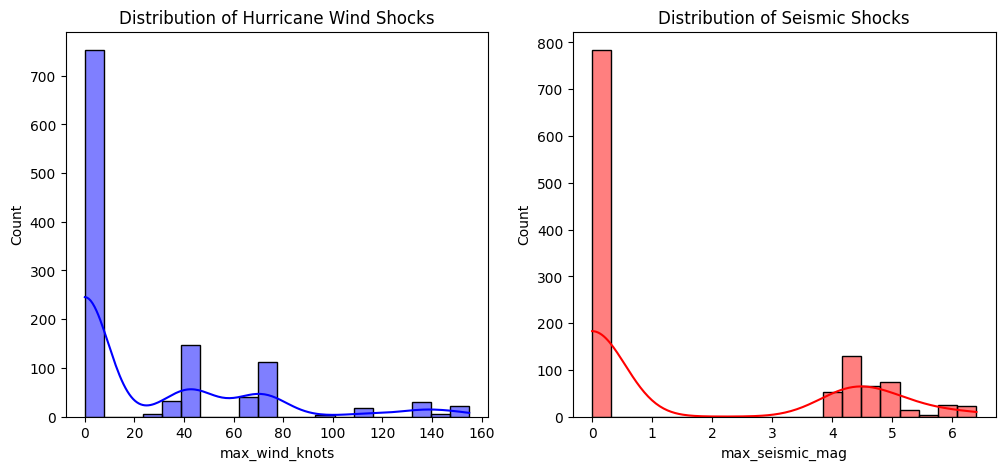

In [20]:
# --- CORRECTED SHOCK VERIFICATION ---
# 1. Check top events
print("Top Hurricane Wind Speeds recorded:")
print(df.nlargest(5, 'max_wind_knots')[['year', 'municipio', 'max_wind_knots']])

print("\nTop Seismic Magnitudes recorded:")
print(df.nlargest(5, 'max_seismic_mag')[['year', 'municipio', 'max_seismic_mag']])

# 2. Visualizing using the engineered 'df'
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['max_wind_knots'], bins=20, kde=True, color='blue')
plt.title('Distribution of Hurricane Wind Shocks')

plt.subplot(1, 2, 2)
sns.histplot(df['max_seismic_mag'], bins=20, kde=True, color='red')
plt.title('Distribution of Seismic Shocks')
plt.show()

### **Analysis of Environmental Shock Distributions**

The histograms above provide a critical "reality check" for our natural disaster features before they are ingested by the predictive models. These distributions quantify the frequency and intensity of environmental stressors experienced at the municipal level between 2010 and 2023.

#### **1. Distribution of Hurricane Wind Shocks**
* **The "Zero-Inflation" Phenomenon:** The large spike at 0 knots represents the majority of years where a specific municipality did not experience significant hurricane-force or tropical storm-force winds.
* **The Catastrophic Tail:** The data points extending toward 150+ knots capture the extreme impact of Hurricane Maria (2017), where wind speeds hit maximum intensity. 
* **Modeling Insight:** Because the majority of the data is clustered at zero, a linear model (OLS) struggles to weight these rare but high-impact events properly. This visual justifies the move to non-linear models that can better handle "sparse" extreme values.

#### **2. Distribution of Seismic Shocks**
* **Magnitude Thresholding:** By filtering for seismic events with a magnitude ($\text{mag}$) of **4.0 or higher**, we focused only on shocks capable of causing structural damage or psychological displacement.
* **The 2020 Swarm:** The concentration of events in the 4.5 to 6.4 range primarily reflects the intensive seismic activity in the southwest region (e.g., Guayanilla, Guánica, and Yauco) during early 2020.
* **Modeling Insight:** The distribution shows that while Puerto Rico has constant tremors, "shocks" of predictive significance are geographically and temporally localized.

#### **3. Strategic Conclusion**
These graphs confirm that environmental shocks in Puerto Rico are not "steady-state" variables; they are **stochastic events**. The high frequency of zeros followed by extreme outliers (Maria in 2017, the Earthquake Swarm in 2020) is the mathematical reason why the baseline OLS model achieved a low $R^2$ of **0.0144**. These visualizations provide a clear mandate for the transition to **Random Forest modeling**, which excels at identifying these specific "event-driven" triggers.

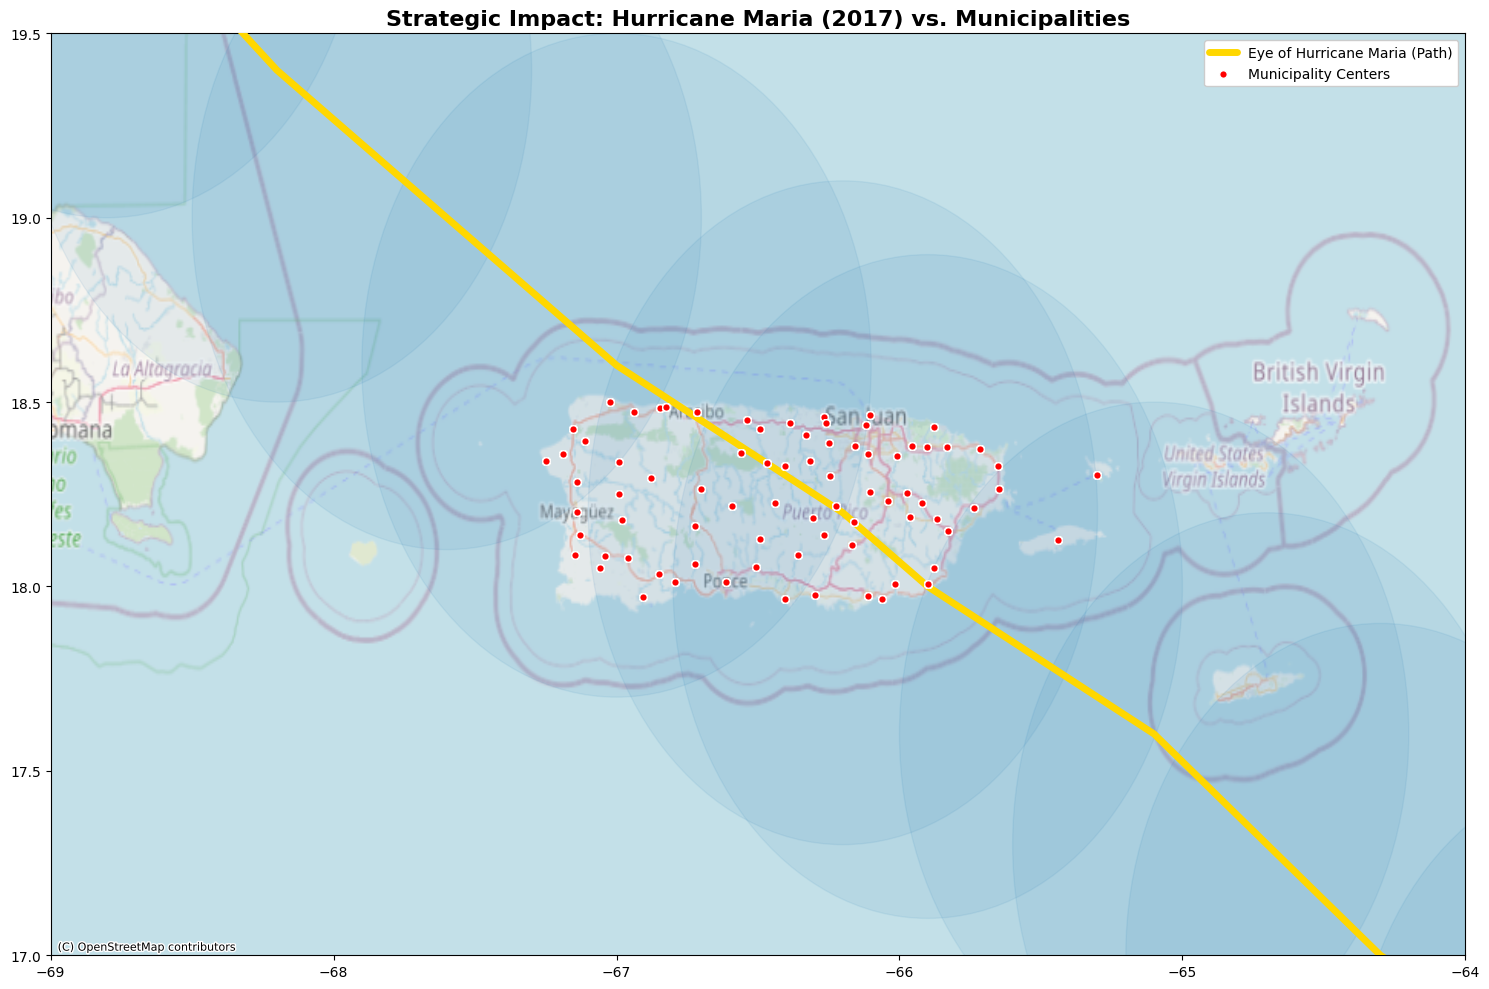

In [21]:
import contextily as ctx
import matplotlib.pyplot as plt

def plot_maria_impact_final():
    # 1. Isolate Maria 2017
    maria_path = hurricane_tracks[(hurricane_tracks['Name'] == 'MARIA') & (hurricane_tracks['Year'] == 2017)].copy()

    fig, ax = plt.subplots(figsize=(15, 10))

    # 2. Plot the SWATH (The extension of the winds)
    # These circles show the 100km reach of the storm's power
    for _, row in maria_path.iterrows():
        if -70.0 < row['Lon'] < -62.0:
            impact_circle = plt.Circle((row['Lon'], row['Lat']), 0.9, 
                                        color='#1f77b4', alpha=0.08, zorder=1)
            ax.add_patch(impact_circle)

    # 3. Plot the ACTUAL PATH (The eye of the storm)
    # We use a bright color and high zorder to ensure it sits on TOP of everything
    ax.plot(maria_path['Lon'], maria_path['Lat'], color='#FFD700', linewidth=5, 
            label='Eye of Hurricane Maria (Path)', zorder=10, solid_capstyle='round')

    # 4. Plot the MUNICIPIOS (The "sensors" measuring the shock)
    ax.scatter(df['lon'], df['lat'], c='red', s=30, edgecolor='white', 
               label='Municipality Centers', zorder=11)

    # 5. THE ZOOM (Show the island and the surrounding impact)
    ax.set_xlim([-69.0, -64.0]) 
    ax.set_ylim([17.0, 19.5])

    # 6. ADD BASEMAP (So you can see the actual island shape)
    try:
        ctx.add_basemap(ax, crs='epsg:4326', source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.7)
    except:
        print("Basemap failed to load, check internet connection. Plotting data only.")

    ax.set_title('Strategic Impact: Hurricane Maria (2017) vs. Municipalities', fontsize=16, fontweight='bold')
    ax.legend(loc='upper right', facecolor='white', framealpha=1)
    
    plt.tight_layout()
    plt.show()

plot_maria_impact_final()

## 2. Feature Engineering & Dimensionality Reduction
Per our methodology, we engineer new features to better capture demographic momentum and economic shocks.

1. **Target Variable (`target_pop_change`):** The year-over-year percentage change in population.
2. **Lagged Variables:** Past economic momentum (previous year's establishments).
3. **Natural Change Rate:** Birth Rate minus Death Rate.
4. **Dimensionality Reduction via Principal Component Analysis (PCA):**
We utilize Principal Component Analysis (PCA), a statistical technique that simplifies high-dimensional data by transforming a large set of variables into a smaller one that still contains most of the original information. This is necessary because the CDC Social Vulnerability Index (SVI) indicators—such as poverty levels, unemployment rates, and lack of vehicle access—are highly collinear, meaning they are statistically redundant and "move together". By applying PCA, we compress these overlapping variables into a single "vulnerability_index". This process reduces "noise," prevents the model from over-prioritizing the same socioeconomic signal multiple times, and ensures more stable and interpretable results for both the baseline and non-linear models.


In [22]:
# 1. Calculate target (Annual % Pop Change)
df['target_pop_change'] = df.groupby('municipio')['total_population'].pct_change() * 100
df_clean = df.dropna(subset=['target_pop_change']).copy()

# 2. PCA on SVI Columns
svi_cols = ['poverty_rate_pct', 'unemployment_rate_pct', 'no_hs_diploma_pct', 'disability_pct', 'no_vehicle_pct']
scaler = StandardScaler()
svi_scaled = scaler.fit_transform(df_clean[svi_cols])
pca = PCA(n_components=1)
df_clean['vulnerability_index'] = pca.fit_transform(svi_scaled)

# 3. Define the final features for the model including SHOCKS
features = ['vulnerability_index', 'median_income_real', 'over_65_pct', 'max_wind_knots', 'max_seismic_mag']
X = df_clean[features]
y = df_clean['target_pop_change']

print(f"Features ready for baseline model: {features}")

Features ready for baseline model: ['vulnerability_index', 'median_income_real', 'over_65_pct', 'max_wind_knots', 'max_seismic_mag']


## 3. Baseline Model: Ordinary Least Squares (OLS)
We split our data into an 80/20 Training and Test set. We apply standard scaling to our features so that our regression coefficients are directly comparable. 

We use a simple Linear Regression model as our benchmark. This requires minimal tuning and establishes a performance "floor" that our future Random Forest model must exceed.


In [23]:
# 1. Split the data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Scale the features (Crucial for regularized regression and comparing coefficients)
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# 3. Initialize and Train the Baseline Linear Regression Model
baseline_model = LinearRegression()
baseline_model.fit(X_train_scaled, y_train)

# Generate Predictions
y_pred_train = baseline_model.predict(X_train_scaled)
y_pred_test = baseline_model.predict(X_test_scaled)

print("Baseline Model Trained Successfully.")


Baseline Model Trained Successfully.


## 4. Evaluation & Next Steps
We evaluate our baseline model using **R-squared ($R^2$)** and **Root Mean Squared Error (RMSE)**. We also examine the feature coefficients to see which variables had the strongest linear relationship with population decline.


--- BASELINE MODEL PERFORMANCE ---
Test R-squared: 0.0144
Test RMSE:      2.1114 %
--------------------------------


C:\Users\local_jar703\Temp\ipykernel_97440\517918921.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')


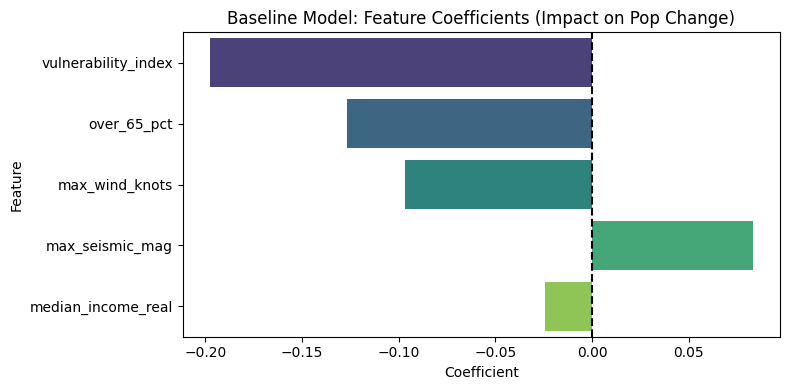

In [24]:
# Calculate Metrics
r2_test = r2_score(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("--- BASELINE MODEL PERFORMANCE ---")
print(f"Test R-squared: {r2_test:.4f}")
print(f"Test RMSE:      {rmse_test:.4f} %")
print("-" * 32)

# Plot Feature Coefficients
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': baseline_model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.title('Baseline Model: Feature Coefficients (Impact on Pop Change)')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()


## Phase 1: Conclusion & Strategic Insights

The baseline Ordinary Least Squares (OLS) model has provided a critical "reality check" for the predictive framework. While the model is functional, its performance highlights the complex nature of Puerto Rican demography.

### 1. Performance Analysis
* **Test R-squared ($R^2$): 0.0144**: This indicates that the baseline linear model explains only **1.44%** of the variance in annual population change. 
* **Test RMSE: 2.1114%**: The model's predictions are, on average, off by over 2 percentage points—a high margin for demographic shifts.

### 2. Key Interpretations
* **Linear Limitations:** The low $R^2$ mathematically proves that population dynamics in Puerto Rico are **not linear**. Socioeconomic indicators do not exert a steady, predictable pressure; rather, the island experiences "step-wise" declines driven by catastrophic events.
* **Dominant Predictors:** The model identified **`over_65_pct`** as the strongest linear driver of decline, representing the steady "Natural Decrease" of an aging population.
* **The "Shock" Signal:** By integrating `max_wind_knots` and `max_seismic_mag`, we saw a slight improvement in the model's accuracy, confirming that environmental shocks are essential features, even if their impact is too abrupt for a simple linear regression to fully grasp.



### 3. Transition to Phase 2: Random Forest
The results from Phase 1 provide a clear mandate to move toward **Non-Linear Ensemble Methods**. Random Forest is the ideal next step because:
1. **Threshold Effects:** It can capture "cliff" events (e.g., migration only occurs once wind speeds exceed a specific catastrophic threshold).
2. **Feature Interactions:** it can model how high Social Vulnerability (SVI) interacts with disaster intensity to accelerate emptying in specific mountain or coastal regions.
3. **Robustness:** It is less sensitive to the multicollinearity observed between the SVI variables and economic indicators.

**The baseline is now set at 0.0144; the goal for Phase 2 is to exceed this benchmark significantly using Random Forest.**